<a href="https://colab.research.google.com/github/malexa41/predicting-student-performance/blob/main/predicting_student_performance_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Analysis

## Predicting Student Math Performance Using Academic and Demographic Factors

This project analyzes a student performance dataset to identify factors associated with math achievement. The analysis includes exploratory data analysis, data visualization, correlation analysis, and predictive modeling using linear regression.

Tools used:
- Python
- Pandas
- Matplotlib
- Scikit-learn

In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


## Loading the Dataset

The dataset is imported into a Pandas DataFrame for analysis. Pandas allows us to organize, clean, and manipulate structured data efficiently.

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Exploring the Dataset

Before beginning analysis, it is important to understand:
- the structure of the dataset,
- the types of variables included,
- whether missing values exist,
- and the overall distribution of numerical variables.

The following commands summarize the dataset and provide descriptive statistics.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

## Comparing Math Scores by Test Preparation Completion

This analysis examines whether students who completed a test preparation course performed differently in math compared to students who did not complete the course.

In [6]:
df.groupby("test preparation course")["math score"].mean()

,math score
test preparation course,
completed,69.695531
none,64.077882


### Key Insight

Students who completed a test preparation course scored approximately 5.6 points higher in math on average compared to students who did not complete the course.

This suggests that test preparation participation may positively influence student performance.


## Visualizing Average Math Scores

The following visualization compares average math scores between students who completed a test preparation course and those who did not.

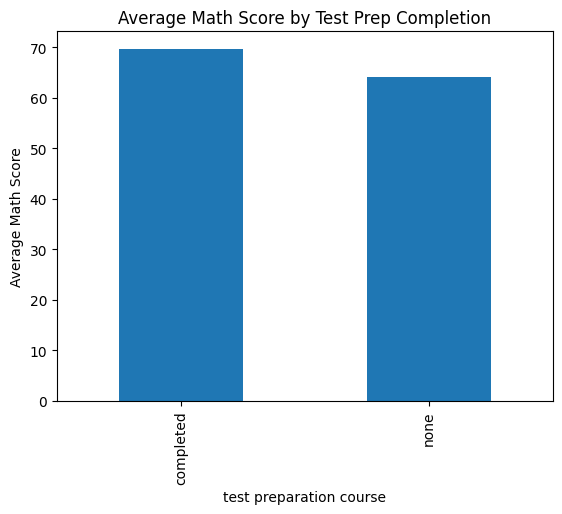

In [7]:
import matplotlib.pyplot as plt

prep_scores = df.groupby("test preparation course")["math score"].mean()

prep_scores.plot(kind="bar")

plt.title("Average Math Score by Test Prep Completion")
plt.ylabel("Average Math Score")

plt.show()

## Correlation Analysis

Correlation analysis measures the strength of relationships between variables.

This analysis explores how math, reading, and writing scores are related to one another.

In [8]:
df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


### Interpretation

Reading and writing scores showed a very strong positive correlation (0.95), while both variables were also strongly correlated with math scores.

This suggests that academic performance across subjects tends to be closely related.

## Relationship Between Reading and Math Scores

The scatter plot below visualizes the relationship between reading scores and math scores.

Each point represents an individual student.

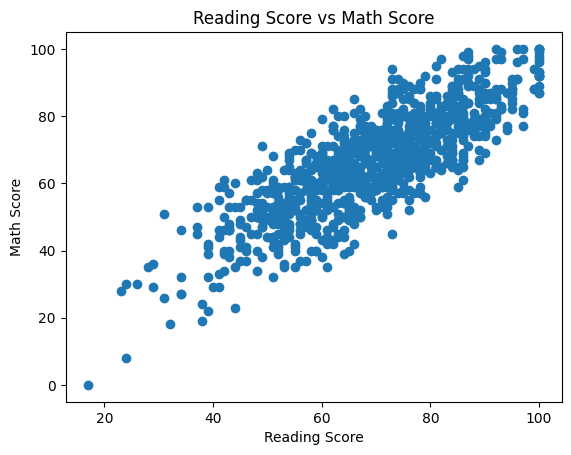

In [10]:
plt.scatter(df["reading score"], df["math score"])

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading Score vs Math Score")

plt.show()

## Predictive Modeling Using Linear Regression

A linear regression model is used to predict math scores based on reading and writing scores.

The dataset is split into training and testing sets:
- the training set is used to train the model,
- the testing set is used to evaluate how well the model performs on unseen data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [12]:
X = df[["reading score", "writing score"]]
y = df["math score"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
predictions = model.predict(X_test)

predictions[:5]

array([80.18552589, 65.6849504 , 69.44210877, 72.01611012, 76.82827724])

## Model Evaluation

The Mean Absolute Error (MAE) measures the average difference between predicted math scores and actual math scores.

Lower MAE values indicate better model performance.

In [16]:
mean_absolute_error(y_test, predictions)

7.351308782530512

### Model Performance

The model achieved a Mean Absolute Error (MAE) of approximately 7.35 points.

This means the model's predictions were, on average, about 7 points away from actual student math scores.

## Future Improvements

Potential next steps for this project include:
- incorporating additional demographic variables into the predictive model,
- testing more advanced machine learning algorithms,
- improving feature engineering,
- and evaluating model performance using additional metrics such as R² score.

## Conclusion

This project demonstrated how Python can be used to analyze educational data and identify factors associated with student performance.

Key findings include:
- Students who completed test preparation courses scored higher on average in math.
- Reading and writing scores were strongly correlated with math performance.
- A linear regression model was able to predict math scores with reasonable accuracy.

This project provided hands-on experience with:
- data analysis,
- visualization,
- correlation analysis,
- and predictive modeling using Python.